# EDA — Dataset CSEDM / ProgSnap2 v6

Análise Exploratória de Dados seguindo o plano definido em `notebooks/EDA_PLAN.md`.  
Metodologia: fase de *Data Preparation* do EDM Process (Kalita et al., 2025).

---

## 1.1 Estatísticas Básicas do Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_ROOT = Path('../data/CSEDM')

In [2]:
# Carregar MainTable do split All (dataset completo)
all_main = pd.read_csv(DATA_ROOT / 'All/Data/MainTable.csv')
print(f'Shape: {all_main.shape}')
all_main.head(3)

Shape: (360176, 17)


,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Run.Program,1.0,NaN,NaN,NaN,11161,11161,NaN
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Compile,NaN,Success,NaN,NaN,11162,11162,11161.0
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:46:46,0,CS 1,439,3,53e05b92cf3e024e5b8c4858d8e02ccd724e1283d53cde...,True,Run.Program,0.0,NaN,NaN,NaN,11163,11163,NaN


### Eventos por tipo (EventType)

In [3]:
event_counts = (
    all_main['EventType']
    .value_counts()
    .rename_axis('EventType')
    .reset_index(name='Count')
)
event_counts['%'] = (event_counts['Count'] / event_counts['Count'].sum() * 100).round(2)
print(event_counts.to_string(index=False))

    EventType  Count     %
  Run.Program 125578 34.87
      Compile 125578 34.87
Compile.Error 109020 30.27


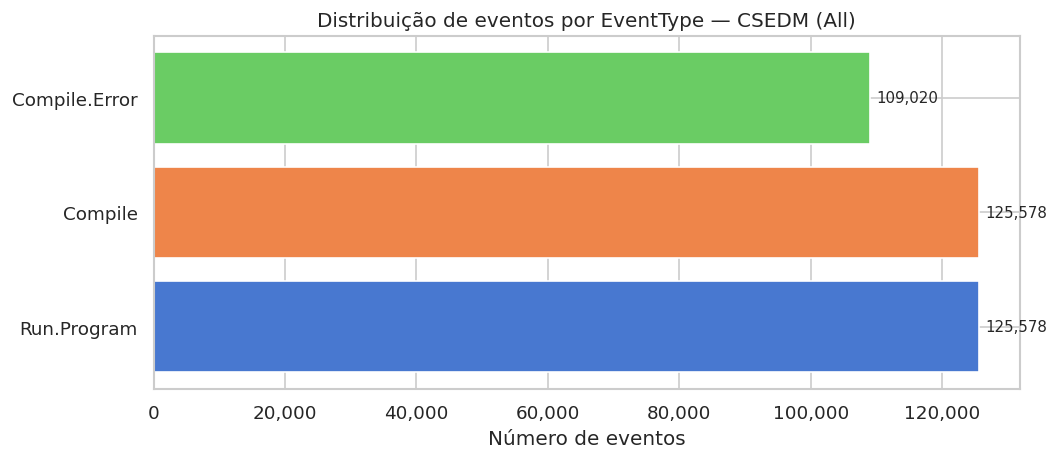

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(event_counts['EventType'], event_counts['Count'], color=sns.color_palette('muted'))
ax.bar_label(bars, labels=[f"{v:,}" for v in event_counts['Count']], padding=4, fontsize=9)
ax.set_xlabel('Número de eventos')
ax.set_title('Distribuição de eventos por EventType — CSEDM (All)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### Entidades únicas: estudantes, assignments, problemas

In [5]:
n_students    = all_main['SubjectID'].nunique()
n_assignments = all_main['AssignmentID'].dropna().nunique()
n_problems    = all_main['ProblemID'].dropna().nunique()
n_events      = len(all_main)

summary = pd.DataFrame({
    'Métrica': ['Total de eventos', 'Estudantes únicos (SubjectID)',
                'Assignments únicos (AssignmentID)', 'Problemas únicos (ProblemID)'],
    'Valor': [f'{n_events:,}', f'{n_students:,}', f'{n_assignments:,}', f'{n_problems:,}']
})
display(summary.set_index('Métrica'))

print('\nAssignmentIDs:', sorted(all_main['AssignmentID'].dropna().unique()))
print('ProblemIDs:   ', sorted(all_main['ProblemID'].dropna().unique()))

,Valor
Métrica,
Total de eventos,"360,176"
Estudantes únicos (SubjectID),506
Assignments únicos (AssignmentID),5
Problemas únicos (ProblemID),50



AssignmentIDs: [np.int64(439), np.int64(487), np.int64(492), np.int64(494), np.int64(502)]
ProblemIDs:    [np.int64(1), np.int64(3), np.int64(5), np.int64(12), np.int64(13), np.int64(17), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(28), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(49), np.int64(51), np.int64(56), np.int64(57), np.int64(64), np.int64(67), np.int64(70), np.int64(71), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(106), np.int64(107), np.int64(108), np.int64(112), np.int64(118), np.int64(128), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(236)]


### Distribuição de estudantes por assignment

Verificar se todos os estudantes participaram dos 5 assignments ou se há dropout ao longo do semestre.

In [6]:
students_per_assignment = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('AssignmentID')['SubjectID']
    .nunique()
    .reset_index(name='Estudantes')
    .sort_values('AssignmentID')
)
students_per_assignment['% do total'] = (
    students_per_assignment['Estudantes'] / n_students * 100
).round(1)
display(students_per_assignment)

,AssignmentID,Estudantes,% do total
0,439,500,98.8
1,487,494,97.6
2,492,494,97.6
3,494,488,96.4
4,502,478,94.5


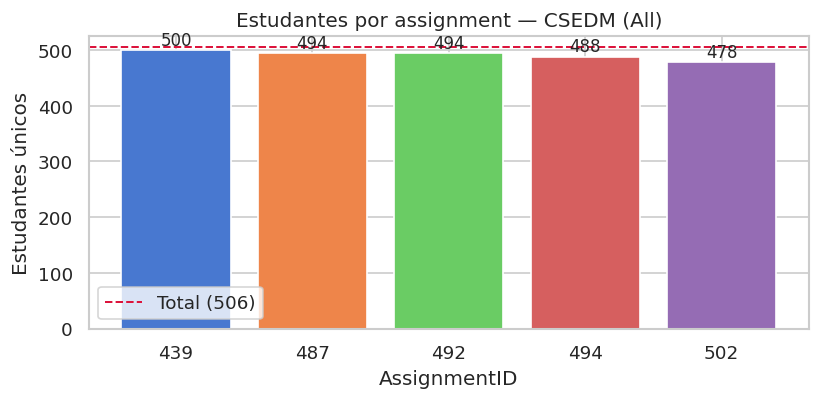

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(
    students_per_assignment['AssignmentID'].astype(str),
    students_per_assignment['Estudantes'],
    color=sns.color_palette('muted')
)
ax.axhline(n_students, color='crimson', linestyle='--', linewidth=1.2, label=f'Total ({n_students})')
for bar, val in zip(ax.patches, students_per_assignment['Estudantes']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('AssignmentID')
ax.set_ylabel('Estudantes únicos')
ax.set_title('Estudantes por assignment — CSEDM (All)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Quantos assignments cada estudante completou (participou de pelo menos 1 evento)
assignments_per_student = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('SubjectID')['AssignmentID']
    .nunique()
    .value_counts()
    .sort_index()
    .reset_index()
)
assignments_per_student.columns = ['Nº de assignments', 'Estudantes']
assignments_per_student['%'] = (
    assignments_per_student['Estudantes'] / n_students * 100
).round(1)
display(assignments_per_student)

full_participants = assignments_per_student.loc[
    assignments_per_student['Nº de assignments'] == n_assignments, 'Estudantes'
].sum()
print(f'\nEstudantes que participaram de TODOS os {n_assignments} assignments: {full_participants} '
      f'({full_participants/n_students*100:.1f}%)')

,Nº de assignments,Estudantes,%
0,1,2,0.4
1,2,5,1.0
2,3,9,1.8
3,4,35,6.9
4,5,455,89.9



Estudantes que participaram de TODOS os 5 assignments: 455 (89.9%)


### Consistência entre splits: Release/Train × Release/Test × All

In [9]:
rel_train = pd.read_csv(DATA_ROOT / 'Release/Train/Data/MainTable.csv')
rel_test  = pd.read_csv(DATA_ROOT / 'Release/Test/Data/MainTable.csv')

splits = {
    'All':           all_main,
    'Release/Train': rel_train,
    'Release/Test':  rel_test,
}

rows = []
for name, df in splits.items():
    rows.append({
        'Split':       name,
        'Eventos':     f"{len(df):,}",
        'Estudantes':  df['SubjectID'].nunique(),
        'Assignments': df['AssignmentID'].dropna().nunique(),
        'Problemas':   df['ProblemID'].dropna().nunique(),
        'EventTypes':  df['EventType'].nunique(),
    })

display(pd.DataFrame(rows).set_index('Split'))

,Eventos,Estudantes,Assignments,Problemas,EventTypes
Split,,,,,
All,"360,176",506,5,50,3
Release/Train,"134,508",246,5,50,3
Release/Test,"32,372",83,3,30,3


In [10]:
train_students = set(rel_train['SubjectID'].unique())
test_students  = set(rel_test['SubjectID'].unique())
all_students   = set(all_main['SubjectID'].unique())
overlap        = train_students & test_students

print(f'Estudantes em Release/Train : {len(train_students)}')
print(f'Estudantes em Release/Test  : {len(test_students)}')
print(f'Sobreposição Train ∩ Test   : {len(overlap)}')
if overlap:
    print('  -> ATENÇÃO: existem estudantes em treino e teste simultaneamente.')
else:
    print('  -> OK: splits mutuamente exclusivos por estudante.')

only_in_all    = all_students - (train_students | test_students)
only_in_splits = (train_students | test_students) - all_students
print(f'\nSubjectIDs em All mas não em Release splits: {len(only_in_all)}')
print(f'SubjectIDs em Release mas não em All       : {len(only_in_splits)}')

total_release = len(train_students) + len(test_students)
print(f'\nRatio Release Train/Test (estudantes): '
      f'{len(train_students)/total_release:.0%} / {len(test_students)/total_release:.0%}')

Estudantes em Release/Train : 246
Estudantes em Release/Test  : 83
Sobreposição Train ∩ Test   : 0
  -> OK: splits mutuamente exclusivos por estudante.

SubjectIDs em All mas não em Release splits: 506
SubjectIDs em Release mas não em All       : 329

Ratio Release Train/Test (estudantes): 75% / 25%
